['8.png', '9.png', '10.png', '4.png', '5.png', '7.png', '6.png', '2.png', '3.png', '1.png']


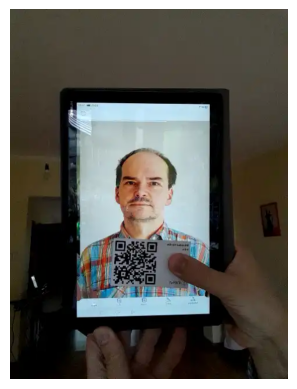

In [21]:
# Opracowanie altrnatywnego sposobu wykrywania ramek
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import cv2.data

# Załadowanie przykładów
image_path = "../../../Dane/Sample/Phone"
#image_path = "../../../Dane/Sample/zd"
#image_path = "../../../Dane/Sample/Default"
files = [f for f in os.listdir(image_path) if f.endswith(".jpg") or f.endswith("jpeg") or f.endswith(".png") or f.endswith(".webp")] # Tylko pliki JPG i PNG i WEBP
print(files)

images = []

for f in files:
    image = cv2.imread(os.path.join(image_path, f))
    images.append(image)

image = images[0]
image = cv2.imread("../../../Dane/Testy projektu/09.27.2022_12-58-23_64007ba5-499c-456d-a78d-a371bd620215-5.webp")
image_original = image

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

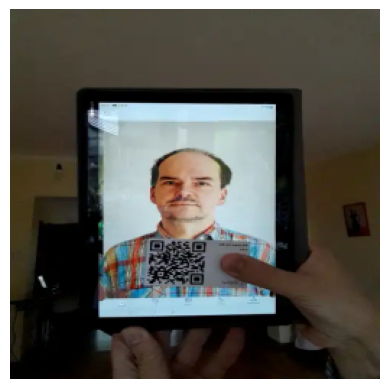

In [22]:
# 0. Downscale
img_downscaled = cv2.resize(image, (256, 256), interpolation=cv2.INTER_AREA)
plt.imshow(cv2.cvtColor(img_downscaled, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

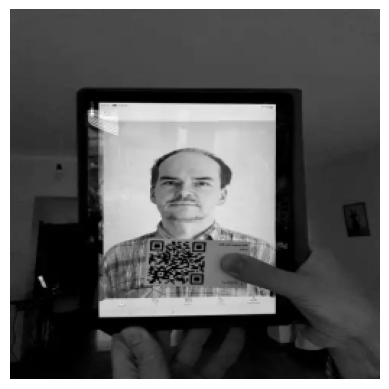

In [23]:
# Wykrycie twarzy
face_classifier = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

image = img_downscaled

# [PARAMETRY]
face = face_classifier.detectMultiScale(image, scaleFactor=1.1, minNeighbors=5)[0]

# Konwersja na skalę szarości
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.show()

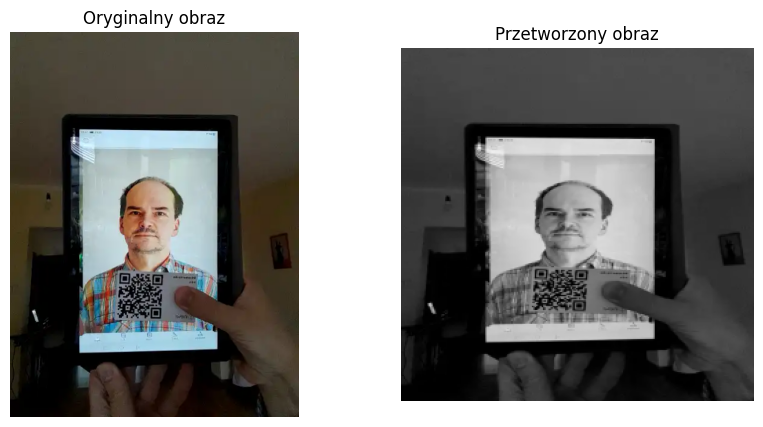

In [24]:
# Do pracy: porównanie oryginalnego i downscaled zdjęcia
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(cv2.cvtColor(image_original, cv2.COLOR_BGR2RGB))
ax[0].set_title("Oryginalny obraz")
ax[0].axis('off')

ax[1].imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))
ax[1].set_title("Przetworzony obraz")
ax[1].axis('off')

plt.show()

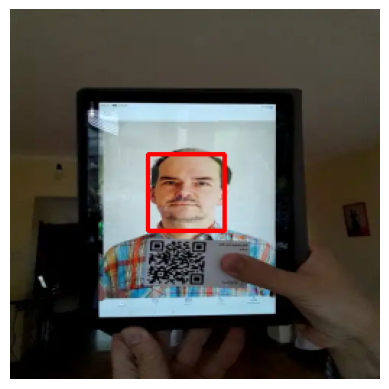

In [25]:
# Wyświetlenie twarzy
cv2.rectangle(image, (face[0], face[1]), (face[0] + face[2], face[1] + face[3]), (0, 0, 255), 2)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

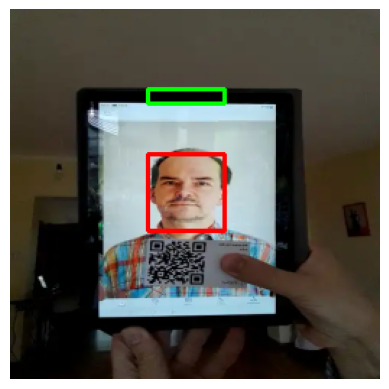

In [26]:
# 1. Ustalenie parametrów początkowych
# 2. Sprawdzenie obecności ramki w "górę"
# 3. Stopniowa zmiana parametrów do minimalnego progu
# 4. Powtórzenie kroku dla pozostałych trzech krawędzi
x, y, w, h = face

bezels_found = 0
face_width = w
face_height = h
max_bezel_size = 30
min_bezel_size = 10
gray_threshold = 28

# Sprawdzanie pikseli "w górę"
x_start = x
y_start = 0
x_end = x + w
y_end = y
current_bezel_size = max_bezel_size
candidates = []

while current_bezel_size >= min_bezel_size:
    # Wybieramy "pasek" o szerokości current_bezel_size
    bezel = gray[y_start:y_start + current_bezel_size, x_start:x_end]
    # Sprawdzamy, czy średnia wartość pikseli w pasku jest mniejsza niż próg
    average = np.mean(bezel)
    if average <= gray_threshold:
        candidates.append((x_start, y_start, x_end, y_start + current_bezel_size, average))
    
    # Przesunięcie paska
    y_start += 1
    
    if y_start + current_bezel_size >= y_end:
        current_bezel_size -= 1
        y_start = 0
        

# Wybieramy kandydata (jeżeli istnieje) o najmniejszej średniej wartości pikseli
if len(candidates) > 0:
    x_start, y_start, x_end, y_end, _ = min(candidates, key=lambda a: a[4])
    cv2.rectangle(image, (x_start, y_start), (x_end, y_end), (0, 255, 0), 2)
    bezels_found += 1
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

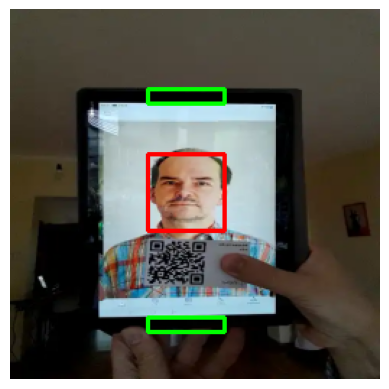

In [27]:
# Powtarzamy dla pozostałych krawędzi
# W "dół"
x_start = x
y_start = y + h
x_end = x + w
y_end = 256
current_bezel_size = max_bezel_size
candidates = []

while current_bezel_size >= min_bezel_size:
    # Wybieramy "pasek" o szerokości current_bezel_size
    bezel = gray[y_start:y_start + current_bezel_size, x_start:x_end]
    # Sprawdzamy, czy średnia wartość pikseli w pasku jest mniejsza niż próg
    average = np.mean(bezel)
    if average <= gray_threshold:
        candidates.append((x_start, y_start, x_end, y_start + current_bezel_size, average))
    
    # Przesunięcie paska
    y_start += 1
    
    if y_start + current_bezel_size >= y_end:
        current_bezel_size -= 1
        y_start = y

# Wybieramy kandydata (jeżeli istnieje) o najmniejszej średniej wartości pikseli
if len(candidates) > 0:
    x_start, y_start, x_end, y_end, _ = min(candidates, key=lambda a: a[4])
    cv2.rectangle(image, (x_start, y_start), (x_end, y_end), (0, 255, 0), 2)
    bezels_found += 1
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

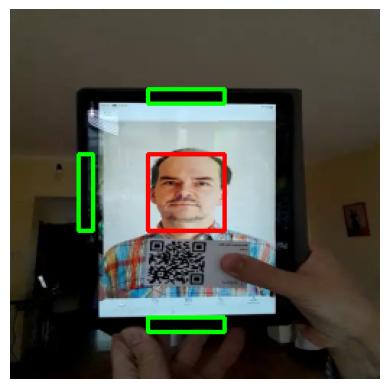

In [28]:
# W "lewo"
x_start = 0
y_start = y
x_end = x
y_end = y + h
current_bezel_size = max_bezel_size
candidates = []

while current_bezel_size >= min_bezel_size:
    # Wybieramy "pasek" o szerokości current_bezel_size
    bezel = gray[y_start:y_end, x_start:x_start + current_bezel_size]
    # Sprawdzamy, czy średnia wartość pikseli w pasku jest mniejsza niż próg
    average = np.mean(bezel)
    if average <= gray_threshold:
        candidates.append((x_start, y_start, x_start + current_bezel_size, y_end, average))
    
    # Przesunięcie paska
    x_start += 1
    
    if x_start + current_bezel_size >= x_end:
        current_bezel_size -= 1
        x_start = 0

# Wybieramy kandydata (jeżeli istnieje) o najmniejszej średniej wartości pikseli
if len(candidates) > 0:
    x_start, y_start, x_end, y_end, _ = min(candidates, key=lambda a: a[4])
    cv2.rectangle(image, (x_start, y_start), (x_end, y_end), (0, 255, 0), 2)
    bezels_found += 1
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

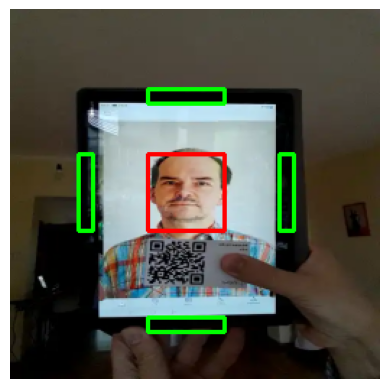

In [29]:
# W "prawo"
x_start = x + w
y_start = y
x_end = 256
y_end = y + h
current_bezel_size = max_bezel_size
candidates = []

while current_bezel_size >= min_bezel_size:
    # Wybieramy "pasek" o szerokości current_bezel_size
    bezel = gray[y_start:y_end, x_start:x_start + current_bezel_size]
    # Sprawdzamy, czy średnia wartość pikseli w pasku jest mniejsza niż próg
    average = np.mean(bezel)
    if average <= gray_threshold:
        candidates.append((x_start, y_start, x_start + current_bezel_size, y_end, average))
    
    # Przesunięcie paska
    x_start += 1
    
    if x_start + current_bezel_size >= x_end:
        current_bezel_size -= 1
        x_start = x
        
# Wybieramy kandydata (jeżeli istnieje) o najmniejszej średniej wartości pikseli
if len(candidates) > 0:
    x_start, y_start, x_end, y_end, _ = min(candidates, key=lambda a: a[4])
    cv2.rectangle(image, (x_start, y_start), (x_end, y_end), (0, 255, 0), 2)
    bezels_found += 1
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

In [30]:
# Sprawdzamy, ile ramek udało się znaleźć
# Jeżeli co najmniej 2, to uznajemy, że znaleźliśmy ramkę urządzenia
if bezels_found >= 2:
    print("Znaleziono ramkę")
else:
    print("Nie znaleziono ramki")

Znaleziono ramkę
